# IBM HR Analytics — Análise dos fatores associados ao desligamento de funcionários

## Objetivo do projeto

O desligamento de funcionários, representado neste conjunto de dados pela variável `Attrition`, pode gerar impactos financeiros e operacionais relevantes para uma organização. Além dos custos envolvidos na contratação e no treinamento de novos profissionais, uma elevada rotatividade pode prejudicar a continuidade das equipes e a retenção de conhecimento interno.

Este projeto tem como objetivo investigar quais características dos funcionários apresentam maior associação com o desligamento, utilizando técnicas de estatística descritiva e inferencial.

A análise será conduzida em diferentes etapas. Inicialmente, será realizada a inspeção e a preparação do conjunto de dados. Em seguida, as variáveis serão classificadas de acordo com sua natureza e analisadas por meio de estatísticas descritivas.

Com base nos padrões observados durante a análise exploratória, serão formuladas hipóteses relacionadas a fatores como horas extras, satisfação, tempo de empresa e salário. Essas hipóteses serão posteriormente avaliadas utilizando testes estatísticos adequados para cada tipo de variável.

Além da significância estatística, também serão calculadas medidas de tamanho de efeito. Essa etapa é importante porque permite avaliar não apenas se uma diferença ou associação existe, mas também qual é a sua magnitude dentro do conjunto de dados analisado.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o conjunto de dados utilizado ao longo da análise
url = "https://raw.githubusercontent.com/guimalucas/IBM_HR_ANALYTICS/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [2]:
df.shape

(1470, 35)

In [3]:
df.dtypes.value_counts()

,count
int64,26
object,9


## Inspeção inicial do conjunto de dados

Antes de iniciar qualquer transformação ou análise estatística, é necessário compreender a estrutura geral do conjunto de dados.

Nesta etapa serão verificadas a quantidade de linhas e colunas, os tipos de dados presentes, os nomes das variáveis e os valores encontrados nas colunas categóricas.

Essa inspeção permite identificar possíveis inconsistências, como tipos de dados inadequados, categorias inesperadas, variáveis constantes ou colunas que não agregam informação à análise.

Neste momento, nenhuma modificação será realizada. O objetivo é apenas conhecer a estrutura original dos dados e reunir informações para planejar corretamente as etapas seguintes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
variaveis_categoricas = df.select_dtypes(include=['object'])
for coluna in variaveis_categoricas.columns:
  print(coluna)
  print(variaveis_categoricas[coluna].unique())
  print()

Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Sales' 'Research & Development' 'Human Resources']

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender
['Female' 'Male']

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus
['Single' 'Married' 'Divorced']

Over18
['Y']

OverTime
['Yes' 'No']



In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Observações da inspeção inicial

O conjunto de dados possui **1.470 registros e 35 variáveis**, reunindo informações demográficas, profissionais, salariais e relacionadas à satisfação dos funcionários.

A maior parte das colunas está armazenada como valores inteiros, enquanto nove variáveis apresentam o tipo `object`, utilizado principalmente para categorias textuais, como `Attrition`, `Department`, `Gender` e `OverTime`.

A inspeção também mostra que algumas variáveis ordinais, como `JobSatisfaction`, `EnvironmentSatisfaction` e `JobLevel`, estão representadas numericamente. Apesar de possuírem valores inteiros, esses códigos representam níveis ou categorias ordenadas e não devem ser interpretados da mesma forma que medidas quantitativas comuns.

Também foram identificadas colunas aparentemente constantes, como `EmployeeCount`, `Over18` e `StandardHours`. Como não apresentam variação entre os funcionários, essas variáveis não contribuem para explicar diferenças no desligamento e serão removidas na etapa de preparação.

## Limpeza e preparação dos dados

A qualidade das análises estatísticas depende diretamente da consistência do conjunto de dados utilizado.

Nesta etapa serão verificadas a presença de valores ausentes e a existência de registros duplicados. Esses problemas poderiam distorcer frequências, médias, proporções e resultados dos testes estatísticos.

Também serão removidas variáveis constantes, pois colunas que apresentam o mesmo valor em todos os registros não possuem poder de diferenciação e não fornecem informação útil para investigar o desligamento dos funcionários.

Embora o IBM HR Analytics seja um conjunto de dados amplamente utilizado para fins educacionais e já apresente uma estrutura relativamente organizada, essas verificações continuam sendo necessárias para documentar a qualidade dos dados e garantir a confiabilidade das etapas posteriores.

In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
colunas_desnecessarias = df[["Over18","EmployeeCount", "StandardHours"]]
df_limpo = df.drop(columns=colunas_desnecessarias)
df_limpo

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,4,0,17,3,2,9,6,0,8


In [10]:
variavel_alvo = df["Attrition"]

In [11]:
for coluna in df_limpo.columns:
  print(coluna)
  print(df_limpo[coluna].unique())
  print()

Age
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DailyRate
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  194  967 1

### Resultado da preparação

Não foram encontrados valores ausentes nem registros duplicados no conjunto de dados.

As colunas `EmployeeCount`, `Over18` e `StandardHours` foram removidas porque apresentavam valores constantes em todos os registros. Como não existia variação nessas variáveis, elas não poderiam contribuir para distinguir funcionários que permaneceram daqueles que deixaram a empresa.

A variável `Attrition` foi mantida como variável-alvo da análise. Ela identifica se o funcionário permaneceu na organização (`No`) ou se ocorreu desligamento (`Yes`).

Após essas verificações, o conjunto de dados encontra-se adequado para a classificação das variáveis e para o início da análise exploratória.

## Classificação das variáveis

Antes de realizar as análises descritivas, as variáveis serão agrupadas de acordo com sua natureza estatística.

Essa classificação é importante porque diferentes tipos de variável exigem formas distintas de interpretação e de análise. Uma média, por exemplo, possui interpretação direta para uma variável quantitativa, mas pode ser inadequada ou limitada para uma categoria nominal.

As variáveis serão organizadas nos seguintes grupos:

- **Quantitativas discretas:** representam contagens ou medidas registradas em valores inteiros, como idade, número de empresas anteriores e anos de experiência;
- **Quantitativas contínuas:** representam medidas numéricas em que diferenças de magnitude são relevantes, como renda mensal e taxas de pagamento;
- **Qualitativas nominais:** representam categorias sem uma ordem natural, como departamento, área de formação e cargo;
- **Qualitativas ordinais:** representam categorias que possuem uma ordem lógica;
- **Ordinais codificadas:** são categorias ordenadas representadas por números, como os níveis de satisfação e envolvimento;
- **Binárias:** apresentam apenas duas possibilidades, como gênero e realização de horas extras.

Essa separação também servirá de apoio para a escolha dos testes estatísticos utilizados na etapa inferencial.

In [12]:
variaveis_quantitativas_discretas = ["Age","NumCompaniesWorked","TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole","YearsSinceLastPromotion", "YearsWithCurrManager"]

variaveis_quantitativas_continuas = ["HourlyRate", "MonthlyIncome", "MonthlyRate", "DailyRate", "DistanceFromHome", "PercentSalaryHike"]

variaveis_qualitativas_ordinais = ["BusinessTravel"]

variaveis_qualitativas_nominais = ["EducationField", "Department", "JobRole", "MaritalStatus"]

variaveis_ordinais_codificadas = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel", "JobSatisfaction", "PerformanceRating", "StockOptionLevel", "TrainingTimesLastYear"]

variaveis_binarias = ["Gender", "OverTime"]

# Análise Exploratória dos Dados

Após a inspeção, a preparação e a classificação das variáveis, inicia-se a Análise Exploratória dos Dados, também conhecida como EDA.

O objetivo desta etapa é compreender a composição do conjunto de dados, identificar padrões, avaliar a distribuição das variáveis e levantar possíveis relações com o desligamento dos funcionários.

Inicialmente será analisada a variável alvo `Attrition`. Em seguida, serão examinadas as estatísticas descritivas dos diferentes grupos de variáveis.

É importante destacar que os resultados desta etapa possuem caráter descritivo. Diferenças observadas em frequências, médias ou proporções podem motivar hipóteses, mas ainda não representam evidências suficientes para afirmar que existe uma associação estatística.

## Distribuição da variável alvo

Antes de investigar os possíveis fatores relacionados ao desligamento, é necessário compreender como a variável `Attrition` está distribuída.

Serão analisadas tanto as frequências absolutas quanto as proporções de funcionários em cada categoria. Essa verificação permite avaliar o equilíbrio entre funcionários que permaneceram e funcionários que deixaram a empresa.

In [13]:
df_limpo['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [14]:
df_limpo['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


### Interpretação da variável-alvo

Dos 1.470 funcionários presentes no conjunto de dados, 1.233 permaneceram na organização e 237 foram desligados.

Isso corresponde a aproximadamente **83,88% de funcionários sem desligamento** e **16,12% com desligamento**.

Existe, portanto, uma diferença considerável entre o tamanho dos dois grupos. Essa característica deve ser levada em consideração ao interpretar quantidades absolutas, pois uma categoria com mais funcionários naturalmente poderá concentrar uma quantidade maior de ocorrências.

Por esse motivo, nas análises seguintes serão utilizadas principalmente taxas e proporções calculadas dentro de cada grupo, evitando conclusões baseadas apenas em contagens absolutas.

## Estatísticas descritivas

As estatísticas descritivas fornecem uma visão geral sobre o comportamento das variáveis do conjunto de dados.

Para as variáveis numéricas serão observadas medidas de tendência central, como média e mediana, medidas de dispersão, como desvio padrão, e medidas de posição, como primeiro e terceiro quartis.

A comparação entre média e mediana auxilia na identificação de possíveis assimetrias. Já os quartis permitem compreender onde se concentra a maior parte dos registros e reduzem a influência de valores extremos.

Para as variáveis categóricas serão observadas a quantidade de categorias, a categoria mais frequente e sua frequência.

As análises serão realizadas separadamente para cada grupo de variáveis, respeitando as diferenças entre suas naturezas estatísticas.

In [15]:
df_limpo[variaveis_quantitativas_discretas].describe()

,Age,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.693197,11.279592,7.008163,4.229252,2.187755,4.123129
std,9.135373,2.498009,7.780782,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.000000,6.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,2.000000,10.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,4.000000,15.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,9.000000,40.000000,40.000000,18.000000,15.000000,17.000000


### Variáveis quantitativas discretas

A idade média dos funcionários é de aproximadamente 36,9 anos, enquanto a mediana é de 36 anos. A proximidade entre essas medidas sugere uma distribuição relativamente equilibrada da idade, com metade dos funcionários possuindo até 36 anos.

Em relação ao tempo total de experiência profissional, a média é de aproximadamente 11,3 anos e a mediana é de 10 anos. Já o tempo médio na empresa atual é de aproximadamente sete anos, enquanto a mediana é de cinco anos.

A diferença entre a média e a mediana de `YearsAtCompany` indica uma distribuição assimétrica à direita. Isso ocorre porque parte dos funcionários possui um tempo de empresa muito elevado, chegando a 40 anos, o que aumenta a média.

O tempo desde a última promoção apresenta média de aproximadamente 2,2 anos e mediana de apenas um ano. Além disso, 75% dos funcionários foram promovidos há, no máximo, três anos. Entretanto, existem registros de até 15 anos sem promoção, indicando a presença de uma parcela menor de funcionários com períodos muito superiores aos valores centrais.

Esses resultados sugerem que variáveis relacionadas à experiência e ao tempo de vínculo possuem distribuições assimétricas, aspecto que será considerado posteriormente na escolha dos testes estatísticos.

In [16]:
df_limpo[variaveis_quantitativas_continuas].describe()


,HourlyRate,MonthlyIncome,MonthlyRate,DailyRate,DistanceFromHome,PercentSalaryHike
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,65.891156,6502.931293,14313.103401,802.485714,9.192517,15.209524
std,20.329428,4707.956783,7117.786044,403.509100,8.106864,3.659938
min,30.000000,1009.000000,2094.000000,102.000000,1.000000,11.000000
25%,48.000000,2911.000000,8047.000000,465.000000,2.000000,12.000000
50%,66.000000,4919.000000,14235.500000,802.000000,7.000000,14.000000
75%,83.750000,8379.000000,20461.500000,1157.000000,14.000000,18.000000
max,100.000000,19999.000000,26999.000000,1499.000000,29.000000,25.000000


### Variáveis quantitativas contínuas

A renda mensal apresenta média de aproximadamente 6.503 e mediana de 4.919. Como a média é consideravelmente superior à mediana, existem indícios de assimetria à direita, causada pela presença de funcionários com rendimentos elevados.

Metade dos funcionários possui renda mensal entre aproximadamente 2.911 e 8.379, enquanto o valor máximo se aproxima de 20 mil. Essa amplitude demonstra uma variação salarial expressiva entre os funcionários.

A distância entre a residência e o trabalho apresenta mediana de sete unidades e média de aproximadamente 9,2. Novamente, a média superior à mediana sugere a existência de funcionários que residem muito mais distantes do que a maioria.

As variáveis relacionadas às taxas diária, horária e mensal apresentam maior proximidade entre médias e medianas. Entretanto, essas medidas representam estruturas específicas do conjunto de dados e não devem ser interpretadas automaticamente como equivalentes diretos do salário mensal.

A assimetria observada em `MonthlyIncome` será especialmente relevante na etapa inferencial, pois favorece a utilização de um teste não paramétrico para comparar os grupos de desligamento.

In [17]:
df_limpo[variaveis_qualitativas_ordinais].describe()

,BusinessTravel
count,1470
unique,3
top,Travel_Rarely
freq,1043


### Variável qualitativa ordinal

A variável `BusinessTravel` possui três categorias e apresenta `Travel_Rarely` como classificação mais frequente, reunindo 1.043 funcionários.

Isso indica que a maior parte dos funcionários realiza viagens profissionais com baixa frequência. Entretanto, essa predominância não permite concluir se a frequência de viagens possui relação com o desligamento, pois seria necessário comparar as taxas de Attrition dentro de cada categoria.

In [18]:
df_limpo[variaveis_qualitativas_nominais].describe()


,EducationField,Department,JobRole,MaritalStatus
count,1470,1470,1470,1470
unique,6,3,9,3
top,Life Sciences,Research & Development,Sales Executive,Married
freq,606,961,326,673


### Variáveis qualitativas nominais

Entre as áreas de formação, `Life Sciences` é a categoria mais frequente. O departamento de `Research & Development` concentra a maior parte dos funcionários, enquanto `Sales Executive` é o cargo mais comum.

Em relação ao estado civil, a categoria `Married` aparece com maior frequência.

Essas informações descrevem a composição predominante do quadro de funcionários. No entanto, uma categoria possuir mais registros não significa que apresente maior probabilidade de desligamento. Para investigar esse tipo de relação, seria necessário calcular a taxa de Attrition dentro de cada categoria.

In [19]:
df_limpo[variaveis_ordinais_codificadas].describe()


,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,StockOptionLevel,TrainingTimesLastYear
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.912925,2.721769,2.729932,2.063946,2.728571,3.153741,0.793878,2.799320
std,1.024165,1.093082,0.711561,1.106940,1.102846,0.360824,0.852077,1.289271
min,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,1.000000,2.000000,3.000000,0.000000,2.000000
50%,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,1.000000,3.000000
75%,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,1.000000,3.000000
max,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,3.000000,6.000000


### Variáveis ordinais codificadas

As variáveis de satisfação e envolvimento apresentam, em geral, medianas próximas de três, indicando concentração em níveis intermediários ou superiores das escalas utilizadas.

`JobSatisfaction` e `EnvironmentSatisfaction` possuem valores entre um e quatro, com medianas iguais a três. Isso sugere que pelo menos metade dos funcionários se encontra nos níveis três ou quatro dessas escalas.

Entretanto, essas médias devem ser interpretadas com cautela. Os números representam categorias ordenadas, e a distância entre os níveis não é necessariamente equivalente a uma medida quantitativa contínua.

Por esse motivo, quando essas variáveis forem comparadas com `Attrition`, serão tratadas como categorias ordinais e avaliadas por meio de tabelas de contingência e do teste Qui-Quadrado.

In [20]:
df_limpo[variaveis_binarias].describe()

,Gender,OverTime
count,1470,1470
unique,2,2
top,Male,No
freq,882,1054


### Variáveis binárias

A variável `Gender` apresenta maior frequência de funcionários classificados como `Male`, totalizando 882 registros.

Já em `OverTime`, a categoria mais frequente é `No`, com 1.054 funcionários, indicando que a maior parte não realiza horas extras.

Essas frequências mostram apenas a composição geral da amostra. Para avaliar a relação dessas variáveis com o desligamento, será necessário calcular a proporção de Attrition dentro de cada categoria.

# Formulação e análise exploratória das hipóteses

A análise descritiva forneceu uma visão geral sobre o comportamento das variáveis, mas ainda não investigou diretamente suas relações com o desligamento.

Nesta etapa serão explorados alguns fatores que podem estar associados ao `Attrition`. O objetivo é observar padrões, comparar proporções e formular hipóteses que serão avaliadas posteriormente por meio de testes estatísticos.

É importante diferenciar duas formas de análise utilizadas nesta seção:

1. **Distribuição dos funcionários desligados entre as categorias:** mostra como os desligamentos estão distribuídos;
2. **Taxa de desligamento dentro de cada categoria:** mostra a probabilidade observada de desligamento entre os funcionários daquela categoria.

Uma categoria pode concentrar muitos desligamentos apenas porque possui mais funcionários. Por isso, sempre que possível, a taxa calculada dentro de cada grupo possui maior relevância para avaliar o risco relativo de desligamento.

Os resultados desta etapa continuarão sendo descritivos. As possíveis associações identificadas serão formalmente avaliadas na seção de testes de hipóteses.

## Idade e desligamento

A primeira análise investiga como os funcionários desligados estão distribuídos entre diferentes faixas etárias.

A utilização de faixas, em vez de analisar cada idade isoladamente, reduz a fragmentação dos dados e facilita a identificação de padrões gerais.

Nesta análise será observada a composição etária dos grupos de funcionários que permaneceram e que foram desligados.

In [21]:
df_hipoteses = df_limpo.copy()

faixas = [17, 25, 35, 45, 55, float('inf')]
rotulos = ['18-25', '26-35', '36-45', '46-55', '56+']

df_hipoteses['FaixaEtaria'] = pd.cut(df_hipoteses['Age'], bins=faixas, labels=rotulos)

df_hipoteses.groupby(['FaixaEtaria'])['Attrition'].value_counts(normalize=True).unstack()*100


/tmp/ipykernel_1617/1514375645.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hipoteses.groupby(['FaixaEtaria'])['Attrition'].value_counts(normalize=True).unstack()*100


Attrition,No,Yes
FaixaEtaria,,
18-25,64.227642,35.772358
26-35,80.858086,19.141914
36-45,90.811966,9.188034
46-55,88.495575,11.504425
56+,82.978723,17.021277


### Interpretação da idade

Os funcionários entre 26 e 35 anos representam a maior parcela dos desligamentos, correspondendo a aproximadamente 48,95% dos funcionários que deixaram a empresa.

Entretanto, essa faixa também possui grande participação no conjunto de funcionários que permaneceram. Portanto, sua elevada quantidade de desligamentos não deve ser interpretada isoladamente como maior risco.

A diferença mais evidente aparece entre os funcionários de 18 a 25 anos. Essa faixa representa aproximadamente 18,57% dos desligados, mas apenas 6,41% dos funcionários que permaneceram.

Em contraste, funcionários de 36 a 45 anos representam aproximadamente 34,47% dos que permaneceram e apenas 18,14% dos desligados.

Esses resultados sugerem uma concentração proporcionalmente maior de funcionários jovens no grupo de desligamento. Contudo, para avaliar precisamente a probabilidade de desligamento em cada faixa seria necessário calcular a taxa de Attrition dentro de cada grupo etário.

In [22]:
df_hipoteses.groupby(['Attrition'])['FaixaEtaria'].value_counts(normalize=True).unstack()*100

FaixaEtaria,18-25,26-35,36-45,46-55,56+
Attrition,,,,,
No,6.407137,39.740470,34.468775,16.220600,3.163017
Yes,18.565401,48.945148,18.143460,10.970464,3.375527


## Tempo de empresa e desligamento

Em seguida, será analisada a distribuição dos funcionários de acordo com o número de anos trabalhados na empresa.

A hipótese exploratória é que funcionários com menor tempo de vínculo podem estar mais representados entre os desligamentos, especialmente durante os primeiros anos de adaptação à organização.

Os valores de `YearsAtCompany` serão agrupados em faixas para facilitar a comparação entre os funcionários que permaneceram e aqueles que deixaram a empresa.

In [23]:
faixas = [0, 5, 10, 15, 20, 25, 30, 35, float('inf')]
rotulos = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36+']

df_hipoteses['FaixaAnosNaEmpresa'] = pd.cut(df_hipoteses['YearsAtCompany'], bins=faixas, labels=rotulos)

df_hipoteses.groupby(['FaixaAnosNaEmpresa'])['Attrition'].value_counts(normalize=True).unstack()*100

/tmp/ipykernel_1617/904914688.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hipoteses.groupby(['FaixaAnosNaEmpresa'])['Attrition'].value_counts(normalize=True).unstack()*100


Attrition,No,Yes
FaixaAnosNaEmpresa,,
0-5,80.054645,19.945355
6-10,87.723214,12.276786
11-15,93.518519,6.481481
16-20,93.055556,6.944444
21-25,90.243902,9.756098
26-30,100.000000,0.000000
31-35,75.000000,25.000000
36+,75.000000,25.000000


In [24]:
df_hipoteses.groupby(['Attrition'])['FaixaAnosNaEmpresa'].value_counts(normalize=True).unstack()*100

FaixaAnosNaEmpresa,0-5,6-10,11-15,16-20,21-25,26-30,31-35,36+
Attrition,,,,,,,,
No,48.630705,32.614108,8.381743,5.560166,3.070539,0.746888,0.746888,0.248963
Yes,66.063348,24.886878,3.167421,2.262443,1.809955,0.000000,1.357466,0.452489


### Interpretação do tempo de empresa

A faixa entre zero e cinco anos concentra aproximadamente 66,06% dos funcionários desligados, enquanto representa cerca de 48,63% dos funcionários que permaneceram.

Nas faixas superiores, a participação relativa entre os desligados tende a diminuir. Funcionários com 11 a 15 anos de empresa, por exemplo, correspondem a aproximadamente 3,17% dos desligamentos e 8,38% dos funcionários sem desligamento.

Esse padrão sugere que os funcionários desligados tendem a possuir menor tempo de vínculo com a empresa.

Entretanto, esta tabela apresenta a distribuição do tempo de empresa dentro de cada situação de Attrition. A diferença entre as distribuições será posteriormente avaliada com o teste de Mann-Whitney, utilizando os valores originais de `YearsAtCompany`.

## Tempo desde a última promoção e desligamento

A ausência de progressão profissional por períodos prolongados pode ser considerada uma possível fonte de insatisfação e, consequentemente, um fator associado ao desligamento.

Para explorar essa possibilidade, os funcionários serão agrupados de acordo com o número de anos desde a última promoção.

Nesta etapa será observada a distribuição dessas faixas entre funcionários que permaneceram e funcionários desligados.

In [25]:
faixas = [0, 5, 10, 15, float('inf')]
rotulos = ['0-5', '6-10', '11-15', '16+']

df_hipoteses['FaixaUltimaPromocao'] = pd.cut(df_hipoteses['YearsSinceLastPromotion'], bins=faixas, labels=rotulos)
df_hipoteses.groupby(['FaixaUltimaPromocao'])['Attrition'].value_counts(normalize=True).unstack()*100

/tmp/ipykernel_1617/715197419.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hipoteses.groupby(['FaixaUltimaPromocao'])['Attrition'].value_counts(normalize=True).unstack()*100


Attrition,No,Yes
FaixaUltimaPromocao,,
0-5,86.350148,13.649852
6-10,81.879195,18.120805
11-15,87.878788,12.121212
16+,0.000000,0.000000


In [26]:
df_hipoteses.groupby(['Attrition'])['FaixaUltimaPromocao'].value_counts(normalize=True).unstack()*100

FaixaUltimaPromocao,0-5,6-10,11-15,16+
Attrition,,,,
No,76.377953,16.010499,7.611549,0.0
Yes,72.440945,21.259843,6.299213,0.0


### Interpretação do tempo desde a última promoção

A maior parte dos funcionários, tanto desligados quanto não desligados, recebeu sua última promoção há no máximo cinco anos.

A faixa de seis a dez anos representa aproximadamente 21,26% dos funcionários desligados e 16,01% dos funcionários que permaneceram, indicando uma concentração proporcionalmente maior entre os desligados.

Entretanto, esse comportamento não se mantém de maneira progressiva nas faixas seguintes. Entre 11 e 15 anos desde a última promoção, a proporção volta a ser menor no grupo de desligamento.

Portanto, os dados não apresentam uma tendência monotônica em que o aumento do tempo sem promoção seja acompanhado continuamente por maior presença de desligamentos. A faixa de seis a dez anos merece atenção, mas não é possível concluir que quanto maior o tempo sem promoção, maior o desligamento.

## Gênero e desligamento

A análise de gênero será realizada de duas maneiras.

Primeiro será observada a distribuição de homens e mulheres entre os funcionários desligados e não desligados. Em seguida, será calculada a taxa de Attrition dentro de cada gênero.

Essa distinção é necessária porque uma maior quantidade absoluta de homens desligados poderia ocorrer simplesmente porque existem mais homens no conjunto de dados.

In [27]:
df_hipoteses.groupby(['Attrition'])['Gender'].value_counts(normalize=True).unstack()*100

Gender,Female,Male
Attrition,,
No,40.632603,59.367397
Yes,36.708861,63.291139


In [28]:
df_hipoteses.groupby(['Gender'])['Attrition'].value_counts(normalize=True).unstack()*100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


### Interpretação do gênero

Os homens representam aproximadamente 63,29% dos funcionários desligados. Entretanto, também representam a maior parte do conjunto de dados, o que torna essa proporção insuficiente para afirmar que possuem maior tendência ao desligamento.

Ao calcular a taxa dentro de cada gênero, observa-se que aproximadamente 17,01% dos homens foram desligados, em comparação com cerca de 14,80% das mulheres.

A diferença entre as taxas é relativamente pequena. Portanto, embora o grupo masculino apresente uma taxa ligeiramente superior, os resultados descritivos não indicam uma diferença tão expressiva quanto a observada em outras variáveis, como horas extras.

## Horas extras e desligamento

A realização frequente de horas extras pode estar relacionada a maior carga de trabalho, dificuldades de equilíbrio entre vida pessoal e profissional e maior desgaste dos funcionários.

Nesta análise será calculada a taxa de desligamento entre funcionários que realizam e que não realizam horas extras.

Também será observada a composição do grupo de desligados para verificar qual proporção realizava `OverTime`.

In [29]:
df_hipoteses.groupby(['OverTime'])['Attrition'].value_counts(normalize=True).unstack()*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [30]:
df_hipoteses.groupby(['Attrition'])['OverTime'].value_counts(normalize=True).unstack()*100

OverTime,No,Yes
Attrition,,
No,76.561233,23.438767
Yes,46.413502,53.586498


### Interpretação das horas extras

Entre os funcionários que não realizam horas extras, aproximadamente 10,44% foram desligados. Entre os que realizam horas extras, a taxa aumenta para aproximadamente 30,53%.

Além disso, embora os funcionários com horas extras representem uma parcela menor do conjunto total, eles correspondem a aproximadamente 53,59% dos funcionários desligados.

A diferença observada é expressiva e sugere uma associação entre `OverTime` e `Attrition`.

Entretanto, os dados não permitem afirmar que as horas extras sejam a causa direta do desligamento. Elas podem estar relacionadas a outros fatores, como cargo, departamento, salário, carga de trabalho ou nível de responsabilidade.

Essa relação será posteriormente avaliada por meio do teste Qui-Quadrado e do V de Cramér.

## Satisfação no trabalho e desligamento

A satisfação com o trabalho pode influenciar o vínculo do funcionário com a organização.

A variável `JobSatisfaction` utiliza uma escala de um a quatro, em que valores menores representam menor satisfação. Para facilitar a interpretação, os níveis serão apresentados com rótulos descritivos.

Será analisada a distribuição dos níveis de satisfação entre os funcionários que permaneceram e os que foram desligados.

In [31]:
faixas = [ 0 ,1, 2, 3, 4]
rotulos = ['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito']

df_hipoteses['FaixaSatisfacao'] = pd.cut(df_hipoteses['JobSatisfaction'], bins=faixas, labels=rotulos)
df_hipoteses.groupby(['FaixaSatisfacao'])['Attrition'].value_counts(normalize=True).unstack()*100

/tmp/ipykernel_1617/1565886640.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hipoteses.groupby(['FaixaSatisfacao'])['Attrition'].value_counts(normalize=True).unstack()*100


Attrition,No,Yes
FaixaSatisfacao,,
Muito Insatisfeito,77.162630,22.837370
Insatisfeito,83.571429,16.428571
Satisfeito,83.484163,16.515837
Muito Satisfeito,88.671024,11.328976


In [32]:
df_hipoteses.groupby(['Attrition'])['FaixaSatisfacao'].value_counts(normalize=True).unstack()*100

FaixaSatisfacao,Muito Insatisfeito,Insatisfeito,Satisfeito,Muito Satisfeito
Attrition,,,,
No,18.085969,18.978102,29.927007,33.008921
Yes,27.848101,19.409283,30.801688,21.940928


### Interpretação da satisfação no trabalho

Funcionários classificados como muito insatisfeitos representam aproximadamente 27,85% dos desligados, enquanto correspondem a cerca de 18,09% dos funcionários que permaneceram.

No extremo oposto, os funcionários muito satisfeitos representam aproximadamente 33,01% dos que permaneceram e apenas 21,94% dos desligados.

Esse padrão sugere que níveis muito baixos de satisfação estão proporcionalmente mais presentes entre os desligamentos, enquanto níveis elevados estão mais presentes entre os funcionários que permaneceram.

Entretanto, as categorias intermediárias apresentam proporções semelhantes entre os grupos. Portanto, a possível associação parece estar concentrada principalmente nos extremos da escala, especialmente entre os funcionários muito insatisfeitos.

# Validação estatística das hipóteses

As análises anteriores permitiram identificar padrões que sugerem possíveis relações entre determinadas características e o desligamento dos funcionários.

Entretanto, diferenças observadas em tabelas ou gráficos podem ocorrer devido à variabilidade natural da amostra. Por esse motivo, serão aplicados testes estatísticos para avaliar se existem evidências suficientes de associação ou diferença entre os grupos.

Para as relações entre duas variáveis categóricas será utilizado o teste Qui-Quadrado de independência. Para as variáveis quantitativas comparadas entre dois grupos independentes será utilizado o teste de Mann-Whitney.

Será adotado um nível de significância de 5%:

- quando o p-valor for inferior a 0,05, a hipótese nula será rejeitada;
- quando o p-valor for igual ou superior a 0,05, não haverá evidência suficiente para rejeitá-la.

Além do p-valor, serão calculados tamanhos de efeito. Essa medida permite diferenciar um resultado apenas estatisticamente significativo de uma associação que também apresenta relevância prática.

## Hipótese 1 — Horas extras e desligamento

A análise exploratória mostrou que a taxa de desligamento entre os funcionários que realizam horas extras é aproximadamente três vezes maior do que entre aqueles que não realizam.

A hipótese investigada é que existe associação entre `OverTime` e `Attrition`.

Para avaliar essa relação, inicialmente será construída uma tabela de contingência com as frequências observadas. Em seguida, será apresentada a taxa de desligamento em cada categoria e aplicado o teste Qui-Quadrado de independência.

Por fim, será calculado o V de Cramér para mensurar a intensidade da associação encontrada.

In [33]:
tabela_overtime = pd.crosstab(df_hipoteses['Attrition'], df_hipoteses['OverTime'])
tabela_overtime

OverTime,No,Yes
Attrition,,
No,944,289
Yes,110,127


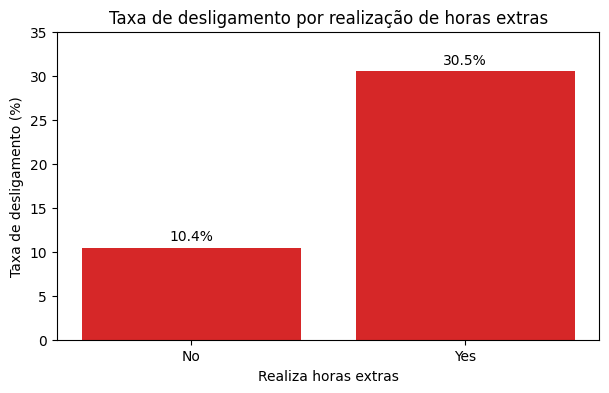

In [34]:
# Calcula a taxa de desligamento em cada categoria de horas extras

grupo_overtime = df_hipoteses.groupby(df_hipoteses['OverTime'])['Attrition'].apply(lambda x: (x == 'Yes').mean()*100)
plt.figure(figsize=(7, 4))

barras = plt.bar(grupo_overtime.index, grupo_overtime.values, color='tab:red')

plt.title('Taxa de desligamento por realização de horas extras')
plt.xlabel('Realiza horas extras')
plt.ylabel('Taxa de desligamento (%)')
plt.ylim(0, 35)
plt.bar_label(barras, fmt='%.1f%%', padding=3)

plt.show()

### Análise descritiva

A tabela de contingência mostra que 127 dos 416 funcionários que realizam horas extras foram desligados, enquanto apenas 110 dos 1.054 funcionários sem horas extras deixaram a empresa.

O gráfico reforça essa diferença: a taxa de desligamento é de aproximadamente 30,53% entre os funcionários com horas extras e 10,44% entre os funcionários sem horas extras.

A diferença é visualmente expressiva. Entretanto, ainda é necessário verificar se ela apresenta significância estatística.

### Teste Qui-Quadrado de independência

O teste Qui-Quadrado será utilizado porque `OverTime` e `Attrition` são variáveis categóricas.

As hipóteses do teste são:

- **H₀:** `OverTime` e `Attrition` são independentes; não existe associação entre as variáveis;
- **H₁:** existe associação entre `OverTime` e `Attrition`.

O teste compara as frequências observadas com as frequências que seriam esperadas caso não existisse associação.

Quando a diferença entre frequências observadas e esperadas é suficientemente grande, o p-valor diminui e fornece evidências contra a hipótese de independência.

In [35]:
# Executa o teste Qui-Quadrado de independência

from scipy.stats import chi2_contingency

qui_quadrado, p_valor, graus_liberdade, frequecias_esperadas = chi2_contingency(tabela_overtime)

print(f"Estatística Qui-Quadrado: {qui_quadrado:.4f}")
print(f"P-valor: {p_valor:.5f}")
print(f"Graus de Liberdade: {graus_liberdade}")
print("Frequências Esperadas:")
print(frequecias_esperadas)

Estatística Qui-Quadrado: 87.5643
P-valor: 0.00000
Graus de Liberdade: 1
Frequências Esperadas:
[[884.06938776 348.93061224]
 [169.93061224  67.06938776]]


### Resultado do teste

O teste apresentou estatística Qui-Quadrado de aproximadamente 87,56 e p-valor muito inferior a 0,05.

Dessa forma, a hipótese nula de independência é rejeitada. Existem evidências estatísticas de associação entre a realização de horas extras e o desligamento.

As frequências esperadas mostram que, caso as variáveis fossem independentes, seriam esperados aproximadamente 67 desligamentos entre os funcionários com horas extras. Entretanto, foram observados 127 casos.

Essa diferença representa quase o dobro do número esperado e é o principal fator responsável pelo elevado valor da estatística Qui-Quadrado.

A significância confirma a existência da associação, mas ainda não informa sua intensidade. Para isso será calculado o V de Cramér.

In [36]:
# Calcula o tamanho do efeito utilizando o V de Cramér

n = tabela_overtime.to_numpy().sum()
linhas, colunas = tabela_overtime.shape

v_cramer = np.sqrt(qui_quadrado/(n * min(linhas - 1, colunas - 1)))

print(f"V de Cramer: {v_cramer:.4f}")

V de Cramer: 0.2441


### Conclusão da hipótese

O V de Cramér foi de aproximadamente **0,244**, indicando uma associação de pequena para moderada magnitude entre horas extras e desligamento.

Entre as variáveis categóricas avaliadas neste projeto, `OverTime` apresentou o maior tamanho de efeito.

Portanto, os resultados sustentam a hipótese de que a realização de horas extras está associada ao Attrition. Funcionários com horas extras apresentam uma taxa de desligamento consideravelmente superior.

Ainda assim, o resultado representa associação e não causalidade. Não é possível afirmar que as horas extras, isoladamente, sejam responsáveis pelo desligamento.

## Hipótese 2 — Satisfação no trabalho e desligamento

A análise exploratória indicou maior presença de funcionários muito insatisfeitos no grupo de desligamento e maior presença de funcionários muito satisfeitos entre aqueles que permaneceram.

A hipótese investigada é que `JobSatisfaction` apresenta associação com `Attrition`.

Como os níveis de satisfação são categorias ordinais codificadas de um a quatro, a relação será avaliada por meio de uma tabela de contingência e do teste Qui-Quadrado.

Também serão calculados os resíduos padronizados para identificar quais combinações de satisfação e desligamento mais contribuem para o resultado do teste. Por fim, o V de Cramér será utilizado para medir a intensidade da associação.

In [37]:
tabela_JobSatisfaction = pd.crosstab(df_limpo['JobSatisfaction'], df_limpo['Attrition'])
tabela_JobSatisfaction

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


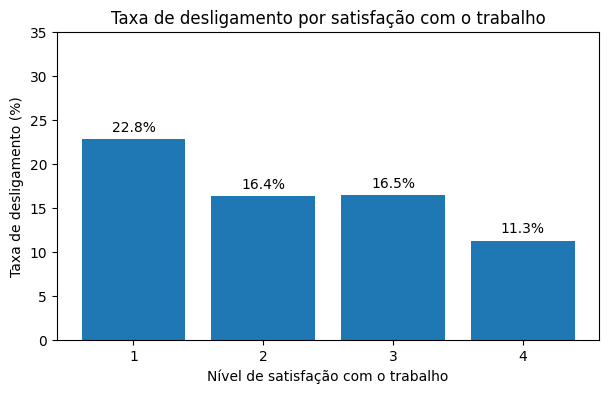

In [38]:
grupo_JobSatisfaction = df_limpo.groupby(df_limpo['JobSatisfaction'])['Attrition'].apply(lambda x: (x == 'Yes').mean()*100)

plt.figure(figsize=(7, 4))
barras = plt.bar(grupo_JobSatisfaction.index, grupo_JobSatisfaction.values, color='tab:blue')
plt.title('Taxa de desligamento por satisfação com o trabalho')
plt.xlabel('Nível de satisfação com o trabalho')
plt.ylabel('Taxa de desligamento (%)')
plt.ylim(0, 35)
plt.bar_label(barras, fmt='%.1f%%', padding=3)
plt.xticks(grupo_JobSatisfaction.index)

plt.show()

### Análise descritiva

A menor categoria de satisfação apresenta a maior taxa de desligamento. Entre os funcionários com `JobSatisfaction = 1`, 66 dos 289 registros correspondem a desligamentos, resultando em uma taxa próxima de 22,84%.

Nos níveis dois e três, as taxas são intermediárias. Já no nível quatro, correspondente à maior satisfação, a taxa de desligamento é menor.

O padrão visual sugere que a insatisfação extrema pode estar relacionada ao Attrition. Entretanto, a relação não é perfeitamente linear em todos os níveis, tornando necessária a avaliação estatística.

### Teste Qui-Quadrado

As hipóteses avaliadas são:

- **H₀:** `JobSatisfaction` e `Attrition` são independentes;
- **H₁:** existe associação entre o nível de satisfação no trabalho e o desligamento.

O teste avaliará simultaneamente as quatro categorias de satisfação.

Após o teste global, os resíduos padronizados serão utilizados para identificar quais células apresentam diferenças relevantes entre frequências observadas e esperadas. Em geral, valores absolutos superiores a aproximadamente dois indicam contribuições importantes para a associação.

In [39]:
qui_quadrado, p_valor, graus_liberdade, frequencias_esperadas = (chi2_contingency(tabela_JobSatisfaction))

print(f"Estatística Qui-Quadrado: {qui_quadrado:.4f}")
print(f"P-valor: {p_valor:.5f}")
print(f"Graus de Liberdade: {graus_liberdade}")
print("Frequencias esperadas:")
print(frequencias_esperadas)

Estatística Qui-Quadrado: 17.5051
P-valor: 0.00056
Graus de Liberdade: 3
Frequencias esperadas:
[[242.40612245  46.59387755]
 [234.85714286  45.14285714]
 [370.73877551  71.26122449]
 [384.99795918  74.00204082]]


### Resultado do teste

O teste apresentou estatística Qui-Quadrado de aproximadamente 17,51 e p-valor de cerca de 0,00056.

Como o p-valor é inferior a 0,05, a hipótese nula é rejeitada. Existem evidências estatísticas de associação entre satisfação no trabalho e desligamento.

Entretanto, o teste global não mostra quais níveis específicos de satisfação são os principais responsáveis pela diferença. Para responder a essa questão, serão analisados os resíduos padronizados.

In [40]:
residuos_JobSatisfaction = (tabela_JobSatisfaction - frequencias_esperadas)/ np.sqrt(frequencias_esperadas)
residuos_JobSatisfaction

Attrition,No,Yes
JobSatisfaction,,
1,-1.246427,2.842984
2,-0.055931,0.127573
3,-0.090305,0.205976
4,1.121331,-2.557650


### Interpretação dos resíduos

A célula correspondente a `JobSatisfaction = 1` e `Attrition = Yes` apresenta resíduo padronizado de aproximadamente 2,84.

Isso significa que foram observados mais desligamentos entre os funcionários muito insatisfeitos do que seria esperado caso as variáveis fossem independentes.

A combinação entre satisfação máxima e ausência de desligamento também apresenta diferença relevante, enquanto a célula de satisfação máxima com desligamento possui resíduo negativo.

Esses resultados mostram que a associação está concentrada principalmente nos extremos da escala, especialmente entre os funcionários muito insatisfeitos.

In [41]:
n = tabela_JobSatisfaction.to_numpy().sum()
linhas, colunas = tabela_JobSatisfaction.shape

v_cramer = np.sqrt(qui_quadrado/(n * min(linhas -1, colunas -1)))

print(f"V de Cramér: {v_cramer:.4f}")

V de Cramér: 0.1091


### Conclusão da hipótese

O V de Cramér foi de aproximadamente **0,109**, indicando uma associação de pequena magnitude.

Portanto, a satisfação no trabalho apresenta associação estatisticamente significativa com o desligamento, mas sua intensidade é limitada quando comparada à relação observada para horas extras.

A hipótese é sustentada principalmente pelo comportamento dos funcionários com o menor nível de satisfação, que apresentaram uma quantidade de desligamentos superior à esperada.

## Hipótese 3 — Satisfação com o ambiente e desligamento

Além da satisfação com o trabalho em si, a percepção do funcionário sobre o ambiente organizacional também pode estar relacionada à sua permanência.

A hipótese investigada é que `EnvironmentSatisfaction` apresenta associação com `Attrition`, especialmente entre funcionários que atribuem o menor nível de satisfação ao ambiente.

A relação será analisada por meio das frequências, taxas de desligamento, teste Qui-Quadrado, resíduos padronizados e V de Cramér.

In [42]:
tabela_EnvironmentSatisfaction = pd.crosstab(df_limpo['EnvironmentSatisfaction'], df_limpo['Attrition'])
tabela_EnvironmentSatisfaction

Attrition,No,Yes
EnvironmentSatisfaction,,
1,212,72
2,244,43
3,391,62
4,386,60


In [43]:
percentuais_EnvironmentSatisfaction = pd.crosstab(df_limpo['EnvironmentSatisfaction'],df_limpo['Attrition'],normalize='index') * 100
percentuais_EnvironmentSatisfaction

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


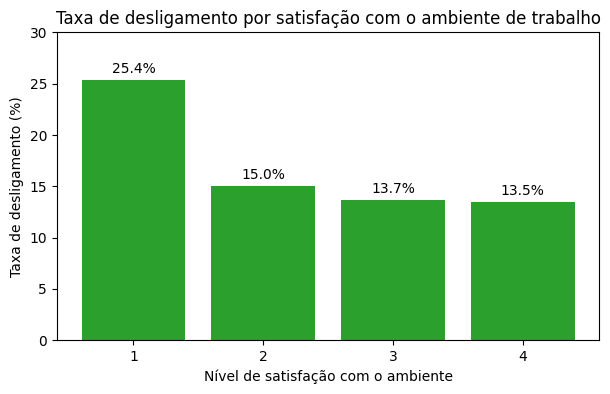

In [44]:
grupo_EnvironmentSatisfaction = df_limpo.groupby(df_limpo['EnvironmentSatisfaction'])['Attrition'].apply(lambda x: (x == 'Yes').mean()*100)

plt.figure(figsize=(7, 4))
barras = plt.bar(grupo_EnvironmentSatisfaction.index, grupo_EnvironmentSatisfaction.values, color='tab:green')
plt.title("Taxa de desligamento por satisfação com o ambiente de trabalho")
plt.xlabel("Nível de satisfação com o ambiente")
plt.ylabel("Taxa de desligamento (%)")
plt.ylim(0, 30)
plt.bar_label(barras, fmt='%.1f%%', padding=3)
plt.xticks(grupo_EnvironmentSatisfaction.index)

plt.show()

### Análise descritiva

A taxa de desligamento entre funcionários com `EnvironmentSatisfaction = 1` é de aproximadamente 25,35%.

Nos demais níveis, as taxas são consideravelmente menores: aproximadamente 14,98% no nível dois, 13,69% no nível três e 13,45% no nível quatro.

O comportamento sugere que a principal diferença está concentrada no menor nível de satisfação. Entre os níveis dois, três e quatro, as taxas são relativamente próximas.

Portanto, os dados não indicam necessariamente uma redução contínua do desligamento a cada aumento da satisfação. O padrão principal é a taxa elevada entre os funcionários muito insatisfeitos com o ambiente.

### Teste Qui-Quadrado

As hipóteses avaliadas são:

- **H₀:** `EnvironmentSatisfaction` e `Attrition` são independentes;
- **H₁:** existe associação entre a satisfação com o ambiente e o desligamento.

Após o teste global, serão analisados os resíduos padronizados para identificar os níveis de satisfação responsáveis pela associação.

In [45]:
qui_quadrado, p_valor, graus_liberdade, frequencias_esperadas = (chi2_contingency(tabela_EnvironmentSatisfaction))

print(f"Estatística Qui-Quadrado: {qui_quadrado:.4f}")
print(f"P-valor: {p_valor:.5f}")
print(f"Graus de Liberdade: {graus_liberdade}")
print("Frequencias esperadas:")
print(frequencias_esperadas)

Estatística Qui-Quadrado: 22.5039
P-valor: 0.00005
Graus de Liberdade: 3
Frequencias esperadas:
[[238.2122449   45.7877551 ]
 [240.72857143  46.27142857]
 [379.96530612  73.03469388]
 [374.09387755  71.90612245]]


### Resultado do teste

O teste apresentou estatística Qui-Quadrado de aproximadamente 22,50 e p-valor próximo de 0,00005.

Como o p-valor é inferior ao nível de significância de 5%, a hipótese nula é rejeitada. Existem evidências de associação entre satisfação com o ambiente e desligamento.

Os resíduos padronizados serão utilizados para localizar as categorias que mais contribuíram para esse resultado.

In [46]:
residuos_EnvironmentSatisfaction = (tabela_EnvironmentSatisfaction - frequencias_esperadas)/np.sqrt(frequencias_esperadas)
residuos_EnvironmentSatisfaction

Attrition,No,Yes
EnvironmentSatisfaction,,
1,-1.698330,3.873732
2,0.210850,-0.480929
3,0.566094,-1.291206
4,0.615574,-1.404066


### Interpretação dos resíduos

A combinação entre `EnvironmentSatisfaction = 1` e `Attrition = Yes` apresenta resíduo padronizado de aproximadamente 3,87.

Esse valor indica que ocorreram mais desligamentos entre os funcionários com o menor nível de satisfação ambiental do que seria esperado em uma situação de independência.

Os resíduos das demais categorias são menores em valor absoluto. Portanto, a associação identificada pelo teste está concentrada principalmente nos funcionários muito insatisfeitos com o ambiente.

In [47]:
n = tabela_EnvironmentSatisfaction.to_numpy().sum()
linhas, colunas = tabela_EnvironmentSatisfaction.shape

v_cramer = np.sqrt(qui_quadrado/(n * min(linhas - 1, colunas - 1)))

print(f"V de Cramér: {v_cramer:.4f}")

V de Cramér: 0.1237


### Conclusão da hipótese

O V de Cramér foi de aproximadamente **0,124**, indicando uma associação de pequena magnitude.

A satisfação com o ambiente apresenta uma associação estatisticamente significativa com o desligamento, mas o efeito é menor do que o observado para horas extras.

Assim como ocorreu com `JobSatisfaction`, o resultado é explicado principalmente pelo grupo com o menor nível de satisfação, e não por uma tendência uniforme ao longo de toda a escala.

## Hipótese 4 — Tempo de empresa e desligamento

A análise exploratória mostrou maior concentração de funcionários com até cinco anos de empresa no grupo de desligamento.

A hipótese investigada é que funcionários desligados apresentam menor tempo de empresa do que aqueles que permaneceram.

Como `YearsAtCompany` é uma variável quantitativa com assimetria e presença de valores extremos, será utilizado o teste não paramétrico de Mann-Whitney.

Antes do teste serão analisados o boxplot e as estatísticas descritivas dos dois grupos. Em seguida, será calculada a correlação bisserial por postos para mensurar o tamanho do efeito.

<Figure size 700x400 with 0 Axes>

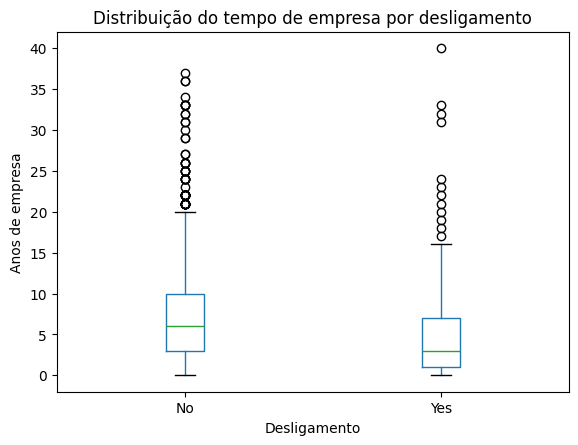

In [48]:
# Visualiza a distribuição do tempo de empresa entre os grupos

plt.figure(figsize=(7,4))

df_limpo.boxplot(column="YearsAtCompany", by='Attrition', grid=False)
plt.title("Distribuição do tempo de empresa por desligamento")
plt.suptitle("")
plt.xlabel("Desligamento")
plt.ylabel("Anos de empresa")

plt.show()

In [49]:
# Separa os funcionários por desligamento e resume estatisticamente cada grupo

anos_sem_desligamentos = df_limpo[df_limpo['Attrition'] == 'No']['YearsAtCompany']
anos_com_desligamento = df_limpo[df_limpo['Attrition'] == 'Yes']['YearsAtCompany']

print("Sem desligamento:")
print(anos_sem_desligamentos.describe())
print()
print("Com desligamento:")
print(anos_com_desligamento.describe())

Sem desligamento:
count    1233.000000
mean        7.369019
std         6.096298
min         0.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        37.000000
Name: YearsAtCompany, dtype: float64

Com desligamento:
count    237.000000
mean       5.130802
std        5.949984
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       40.000000
Name: YearsAtCompany, dtype: float64


### Análise descritiva

Os funcionários que permaneceram possuem média de aproximadamente 7,37 anos de empresa e mediana de seis anos.

Entre os funcionários desligados, a média é de aproximadamente 5,13 anos e a mediana é de três anos.

Os quartis também são inferiores no grupo de desligamento. Enquanto 75% dos funcionários desligados possuem até sete anos de empresa, o terceiro quartil do grupo sem desligamento é de dez anos.

O boxplot e as estatísticas descritivas indicam que os funcionários desligados tendem a possuir menor tempo de vínculo.

Também existem valores extremos e assimetria nos dois grupos. Por esse motivo, o teste de Mann-Whitney é mais adequado do que uma comparação paramétrica baseada apenas nas médias.

### Teste de Mann-Whitney

O teste de Mann-Whitney compara a posição das distribuições de dois grupos independentes sem exigir que os dados sigam uma distribuição normal.

As hipóteses avaliadas são:

- **H₀:** não existe diferença sistemática entre as distribuições de `YearsAtCompany` nos dois grupos;
- **H₁:** existe diferença entre as distribuições.

Um p-valor inferior a 0,05 indicará evidências de que o tempo de empresa apresenta comportamento diferente entre funcionários desligados e não desligados.

In [50]:
# Executa o teste de Mann-Whitney para comparar as distribuições

from scipy.stats import mannwhitneyu

u, p_valor = mannwhitneyu(anos_sem_desligamentos, anos_com_desligamento, alternative='two-sided')

print(f'Estatística U: {u:.2f}')
print(f'P-valor: {p_valor:.4f}')

Estatística U: 189639.00
P-valor: 0.0000


### Resultado do teste

O teste apresentou p-valor inferior a 0,05, permitindo rejeitar a hipótese nula.

Existem evidências estatísticas de diferença entre as distribuições do tempo de empresa nos grupos de funcionários desligados e não desligados.

Considerando as medianas, os quartis e o comportamento visual do boxplot, os funcionários que permaneceram tendem a possuir maior tempo de empresa.

A significância estatística será complementada pela correlação bisserial por postos, que indicará a magnitude dessa diferença.

In [51]:
# Calcula o tamanho do efeito utilizando a correlação bisserial por postos

n1 = len(anos_sem_desligamentos)
n2 = len(anos_com_desligamento)

rank_biserial = 1 - (2*u)/(n1*n2)
print(f"Correlação Biserial: {rank_biserial:.4f}")

Correlação Biserial: -0.2979


### Conclusão da hipótese

A correlação bisserial por postos apresentou valor de aproximadamente **-0,298**.

O sinal negativo representa a direção decorrente da ordem utilizada na comparação dos grupos. Para interpretar a magnitude, considera-se o valor absoluto, aproximadamente 0,298.

Esse resultado indica um efeito de pequena para moderada magnitude, próximo da faixa moderada.

Portanto, os resultados sustentam a hipótese de que funcionários desligados tendem a possuir menor tempo de empresa. Entre as variáveis avaliadas, `YearsAtCompany` apresentou uma das diferenças mais relevantes.

## Hipótese 5 — Renda mensal e desligamento

A renda pode estar relacionada à percepção de reconhecimento, competitividade salarial e permanência do funcionário na organização.

A hipótese investigada é que os funcionários desligados apresentam rendas mensais menores do que aqueles que permaneceram.

Como `MonthlyIncome` possui distribuição assimétrica e grande amplitude, a comparação será realizada por meio do teste de Mann-Whitney.

Também será utilizada a correlação bisserial por postos para avaliar a magnitude da diferença entre os grupos.

<Figure size 700x400 with 0 Axes>

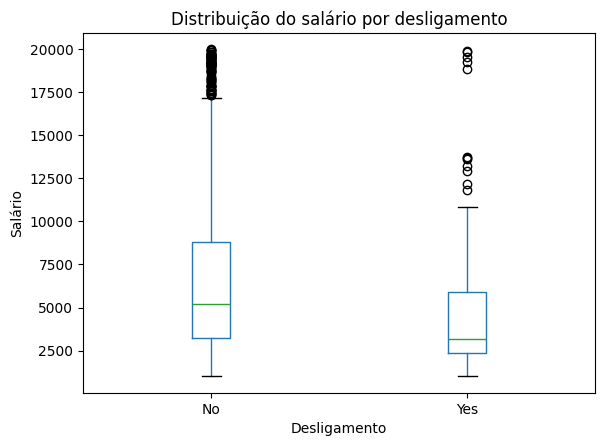

In [52]:
plt.figure(figsize=(7,4))

df_limpo.boxplot(column="MonthlyIncome", by='Attrition', grid=False)
plt.title("Distribuição do salário por desligamento")
plt.suptitle("")
plt.xlabel("Desligamento")
plt.ylabel("Salário")

plt.show()

In [53]:
salario_sem_desligamentos = df_limpo[df_limpo['Attrition'] == 'No']['MonthlyIncome']
salario_com_desligamentos = df_limpo[df_limpo['Attrition'] == 'Yes']['MonthlyIncome']

print("Sem desligamento:")
print(salario_sem_desligamentos.describe())
print()
print("Com desligamento:")
print(salario_com_desligamentos.describe())

Sem desligamento:
count     1233.000000
mean      6832.739659
std       4818.208001
min       1051.000000
25%       3211.000000
50%       5204.000000
75%       8834.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

Com desligamento:
count      237.000000
mean      4787.092827
std       3640.210367
min       1009.000000
25%       2373.000000
50%       3202.000000
75%       5916.000000
max      19859.000000
Name: MonthlyIncome, dtype: float64


### Análise descritiva

Os funcionários que permaneceram apresentam renda média de aproximadamente 6.833 e mediana de 5.204.

Entre os funcionários desligados, a média é de aproximadamente 4.787 e a mediana é de 3.202.

Os quartis também são inferiores no grupo de desligamento. O terceiro quartil dos funcionários desligados é de aproximadamente 5.916, enquanto no grupo que permaneceu é de aproximadamente 8.834.

A diferença entre médias e medianas dentro de cada grupo confirma a assimetria salarial. Por isso, a mediana e os quartis são especialmente importantes para a interpretação, e o teste de Mann-Whitney é adequado para a comparação inferencial.

### Teste de Mann-Whitney

As hipóteses avaliadas são:

- **H₀:** não existe diferença sistemática entre as distribuições de renda mensal dos funcionários desligados e não desligados;
- **H₁:** existe diferença entre as distribuições.

O teste será aplicado aos valores originais de `MonthlyIncome`, sem necessidade de agrupá-los em faixas.

In [54]:
u_salario, p_valor = mannwhitneyu(salario_sem_desligamentos, salario_com_desligamentos, alternative='two-sided')

print(f'Estatística U: {u_salario:.2f}')
print(f'P-valor: {p_valor:.4f}')

Estatística U: 191600.50
P-valor: 0.0000


### Resultado do teste

O p-valor obtido foi inferior a 0,05, permitindo rejeitar a hipótese nula.

Existem evidências estatísticas de diferença entre as distribuições de renda mensal dos dois grupos.

A análise descritiva mostra que funcionários desligados apresentam mediana e quartis salariais inferiores. Portanto, a diferença estatística ocorre na direção esperada pela hipótese.

A correlação bisserial por postos será utilizada para avaliar a magnitude prática dessa diferença.

In [55]:
n1 = len(salario_sem_desligamentos)
n2 = len(salario_com_desligamentos)

rank_biserial = 1 - (2*u_salario)/(n1*n2)

print(f"Correlação Biserial: {rank_biserial:.4f}")

Correlação Biserial: -0.3113


### Conclusão da hipótese

A correlação bisserial por postos apresentou valor de aproximadamente **-0,311**.

Considerando seu valor absoluto, o tamanho do efeito é de aproximadamente 0,311, indicando uma diferença de magnitude moderada.

Entre as variáveis quantitativas analisadas, `MonthlyIncome` apresentou o maior tamanho de efeito.

Portanto, os resultados sustentam a hipótese de que os funcionários desligados tendem a apresentar rendas mensais inferiores às dos funcionários que permaneceram.

Entretanto, não é possível concluir que o menor salário seja a causa direta do desligamento. A renda também pode estar relacionada a cargo, senioridade, idade, experiência profissional e nível hierárquico.

# Resumo dos testes de hipóteses

Ao longo da análise inferencial foram avaliadas cinco hipóteses formuladas a partir dos padrões identificados durante a exploração dos dados.

Para as variáveis categóricas foram utilizados o teste Qui-Quadrado e o V de Cramér. Para as variáveis quantitativas foram utilizados o teste de Mann-Whitney e a correlação bisserial por postos.

A tabela a seguir sintetiza os testes utilizados, os resultados de significância e os tamanhos de efeito encontrados.

| Hipótese analisada | Teste estatístico | p-valor | Tamanho do efeito | Interpretação |
|---|---|---:|---:|---|
| OverTime × Attrition | Qui-Quadrado | < 0,001 | V = 0,244 | Associação significativa de pequena para moderada magnitude |
| JobSatisfaction × Attrition | Qui-Quadrado | < 0,001 | V = 0,109 | Associação significativa de pequena magnitude |
| EnvironmentSatisfaction × Attrition | Qui-Quadrado | < 0,001 | V = 0,124 | Associação significativa de pequena magnitude |
| YearsAtCompany × Attrition | Mann-Whitney | < 0,001 | \|RBC\| = 0,298 | Diferença significativa de pequena para moderada magnitude |
| MonthlyIncome × Attrition | Mann-Whitney | < 0,001 | \|RBC\| = 0,311 | Diferença significativa de magnitude moderada |

## Discussão integrada dos resultados

Todas as cinco hipóteses avaliadas apresentaram resultados estatisticamente significativos. Entretanto, os tamanhos de efeito mostram que as variáveis não possuem a mesma relevância prática.

`MonthlyIncome` apresentou o maior tamanho de efeito entre as variáveis quantitativas, seguido por `YearsAtCompany`. Os funcionários desligados apresentaram rendas mensais e tempos de empresa inferiores aos funcionários que permaneceram.

Entre as variáveis categóricas, `OverTime` apresentou a associação mais intensa. A taxa de desligamento foi aproximadamente três vezes maior entre os funcionários que realizavam horas extras.

`JobSatisfaction` e `EnvironmentSatisfaction` também apresentaram associação significativa, mas com efeitos pequenos. Em ambos os casos, os resíduos padronizados demonstraram que a associação se concentra principalmente nos funcionários classificados no menor nível de satisfação.

De maneira geral, as variáveis relacionadas às condições objetivas do vínculo entre funcionário e empresa — renda, tempo de empresa e horas extras — apresentaram tamanhos de efeito superiores aos indicadores de satisfação analisados.

Isso não significa que a satisfação seja irrelevante. Os resultados indicam apenas que, dentro deste conjunto de dados e entre as hipóteses testadas, suas associações foram menores.

# Conclusão

Este projeto teve como objetivo investigar quais características dos funcionários apresentavam maior associação com o desligamento no conjunto de dados IBM HR Analytics.

A análise começou pela inspeção, limpeza e classificação das variáveis. Em seguida, foram utilizadas estatísticas descritivas para compreender a composição dos dados e identificar padrões relacionados ao Attrition.

Durante a análise exploratória, foram observadas diferenças relevantes associadas às horas extras, ao tempo de empresa, à renda mensal e aos níveis de satisfação. Essas observações deram origem a cinco hipóteses, posteriormente avaliadas com testes estatísticos.

Os resultados mostraram que todas as relações testadas apresentaram significância estatística. Entretanto, a análise dos tamanhos de efeito revelou diferenças importantes entre elas.

A renda mensal apresentou o maior tamanho de efeito entre as variáveis quantitativas, seguida pelo tempo de empresa. Os funcionários desligados tendem a possuir salários menores e vínculos mais curtos com a organização.

A realização de horas extras apresentou a associação mais forte entre as variáveis categóricas. Funcionários que realizavam horas extras apresentaram uma taxa de desligamento substancialmente superior.

Os indicadores de satisfação também apresentaram associação com o Attrition, especialmente entre os funcionários classificados nos menores níveis. No entanto, seus tamanhos de efeito foram inferiores aos observados para renda, tempo de empresa e horas extras.

Portanto, os resultados sugerem que o desligamento é um fenômeno multifatorial. Nenhuma variável isolada explica completamente a saída dos funcionários, mas algumas características podem ser utilizadas como sinais de atenção para apoiar estratégias de retenção.

Por fim, todas as conclusões devem ser interpretadas como associações observadas neste conjunto de dados. Os testes utilizados não demonstram relações de causa e efeito.

# Recomendações

Com base nos resultados obtidos, algumas ações podem ser consideradas em contextos organizacionais semelhantes:

### Monitoramento dos primeiros anos de vínculo

Os funcionários desligados apresentaram menor tempo de empresa. Isso sugere a importância de acompanhar com maior atenção os primeiros anos do vínculo, período em que podem ocorrer dificuldades de adaptação, desalinhamento de expectativas ou ausência de perspectivas de desenvolvimento.

Programas estruturados de integração, acompanhamento periódico e conversas de carreira podem auxiliar na identificação antecipada desses problemas.

### Avaliação da política de horas extras

A realização de horas extras apresentou a associação categórica mais relevante com o desligamento.

A empresa poderia monitorar equipes e cargos com carga recorrente de horas extras, investigando se essa prática está relacionada a falta de pessoal, distribuição inadequada de tarefas, prazos excessivos ou dificuldades de gestão.

### Análise da competitividade salarial

Funcionários desligados apresentaram rendas mensais inferiores às dos que permaneceram.

Isso indica a importância de avaliar a competitividade salarial considerando cargo, experiência, senioridade e mercado. Entretanto, decisões de remuneração não devem ser tomadas apenas com base na relação bivariada observada, pois salário está associado a diversas outras características profissionais.

### Acompanhamento dos níveis mais baixos de satisfação

As associações de `JobSatisfaction` e `EnvironmentSatisfaction` foram pequenas, mas os funcionários com o menor nível de satisfação apresentaram desligamentos acima do esperado.

Pesquisas internas e conversas de acompanhamento podem ser utilizadas para identificar funcionários em situações extremas de insatisfação e compreender os fatores específicos envolvidos.

### Uso conjunto dos indicadores

As variáveis não devem ser utilizadas isoladamente para classificar funcionários.

Uma abordagem mais adequada seria combinar informações sobre carga de trabalho, remuneração, tempo de empresa, satisfação e características do cargo, preservando a privacidade dos funcionários e evitando decisões discriminatórias.